# Notebook 2 — Exploratory Data Analysis

This notebook explores customer churn patterns and identifies
key factors associated with customer attrition.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

## Load Clean Dataset

We load the processed dataset created in Notebook 1.

In [2]:
df = pd.read_csv("C:/Users/hlias/Desktop/telco-churn-prediction/data/processed/telco_churn_clean.csv")

df.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,0,1,0,0,1,0,0,0,0,0,0,1,0,0,0,0,0,0,0,0,0,0,1,0,1,0
1,0,34,56.95,1889.50,0,1,0,0,1,0,0,0,0,0,1,0,0,0,1,0,0,0,0,0,0,1,0,0,0,0,1
2,0,2,53.85,108.15,1,1,0,0,1,0,0,0,0,0,1,0,1,0,0,0,0,0,0,0,0,0,0,1,0,0,1
3,0,45,42.30,1840.75,0,1,0,0,0,1,0,0,0,0,1,0,0,0,1,0,1,0,0,0,0,1,0,0,0,0,0
4,0,2,70.70,151.65,1,0,0,0,1,0,0,1,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,1,0,1,0


## Churn Distribution

We examine the overall churn rate in the dataset.

In [3]:
churn_counts = df["Churn"].value_counts(normalize=True)

churn_counts

Churn
0    0.734215
1    0.265785
Name: proportion, dtype: float64

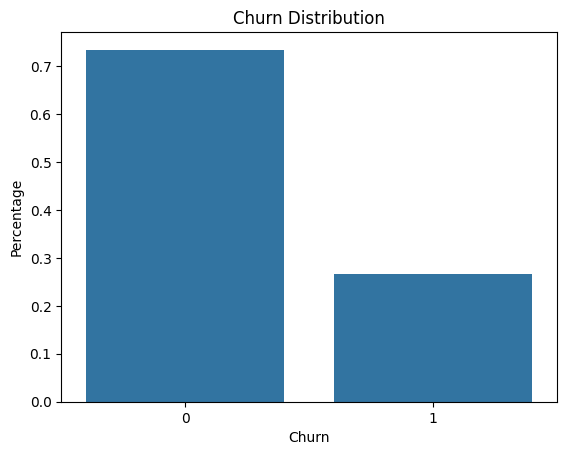

In [4]:
plt.figure()
sns.barplot(x=churn_counts.index, y=churn_counts.values)
plt.title("Churn Distribution")
plt.ylabel("Percentage")
plt.xlabel("Churn")
plt.savefig("../outputs/figures/churn_distribution.png", bbox_inches="tight")
plt.show()

## Churn by Contract Type

We analyze how contract duration affects churn.

In [5]:
contract_cols = [col for col in df.columns if "Contract_" in col]

contract_churn = df.groupby("Churn")[contract_cols].mean().T
contract_churn

Churn,0,1
Contract_One year,0.252954,0.088818
Contract_Two year,0.317064,0.025682


## Monthly Charges vs Churn

We compare monthly charges between churned and retained customers.

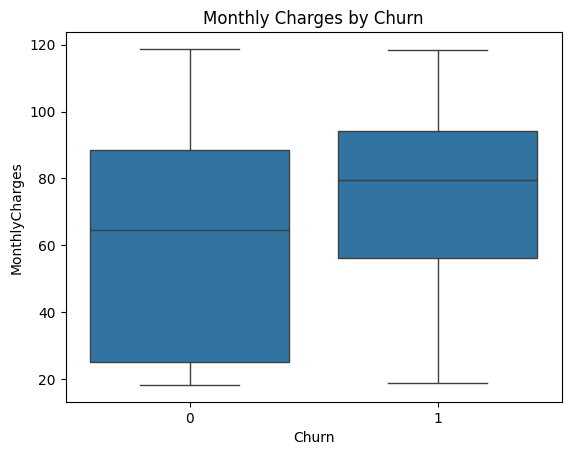

In [6]:
plt.figure()
sns.boxplot(x="Churn", y="MonthlyCharges", data=df)
plt.title("Monthly Charges by Churn")
plt.show()

## Tenure Analysis

We analyze how customer tenure affects churn.

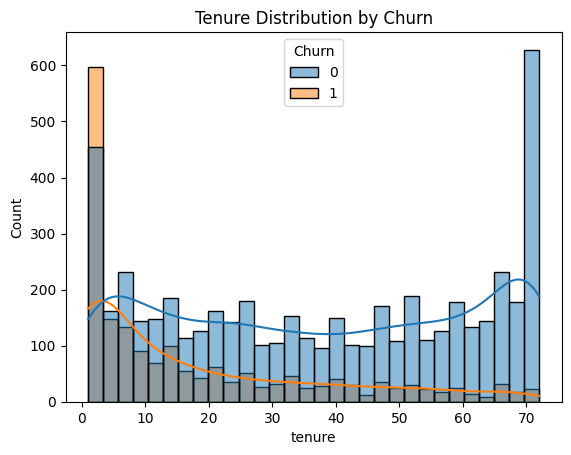

In [7]:
plt.figure()
sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True)
plt.title("Tenure Distribution by Churn")
plt.show()

## Internet Service Type

We examine churn differences across internet service types.

In [8]:
internet_cols = [col for col in df.columns if "InternetService_" in col]

df[internet_cols + ["Churn"]].groupby("Churn").mean().T

Churn,0,1
InternetService_Fiber optic,0.348441,0.693954
InternetService_No,0.272516,0.060460


## Feature Correlation with Churn

We inspect correlations between numerical features and churn.

In [9]:
corr = df.corr()["Churn"].sort_values(ascending=False)
corr

Churn                                    1.000000
InternetService_Fiber optic              0.307463
PaymentMethod_Electronic check           0.301455
MonthlyCharges                           0.192858
PaperlessBilling_Yes                     0.191454
SeniorCitizen                            0.150541
StreamingTV_Yes                          0.063254
StreamingMovies_Yes                      0.060860
MultipleLines_Yes                        0.040033
PhoneService_Yes                         0.011691
gender_Male                             -0.008545
MultipleLines_No phone service          -0.011691
DeviceProtection_Yes                    -0.066193
OnlineBackup_Yes                        -0.082307
PaymentMethod_Mailed check              -0.090773
PaymentMethod_Credit card (automatic)   -0.134687
Partner_Yes                             -0.149982
Dependents_Yes                          -0.163128
TechSupport_Yes                         -0.164716
OnlineSecurity_Yes                      -0.171270


## Key EDA Insights

- Month-to-month contracts drive higher churn
- Higher monthly charges are associated with churn
- Customers with low tenure are more likely to leave
- Fiber optic internet customers show higher churn risk